# Test loss plots

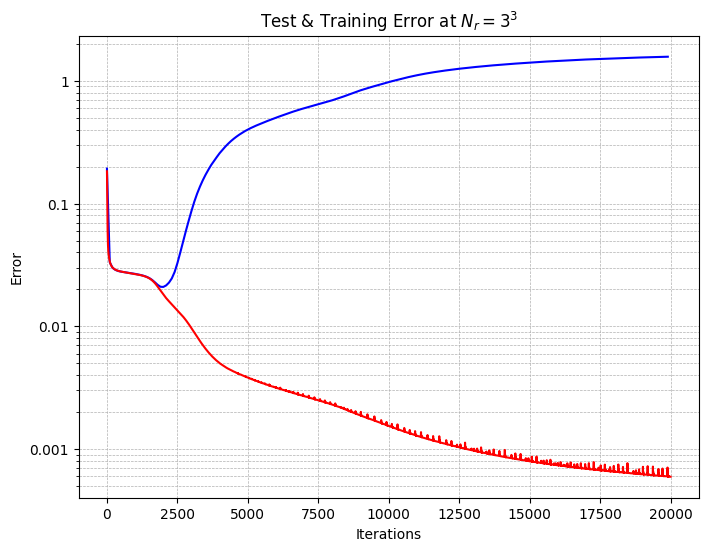

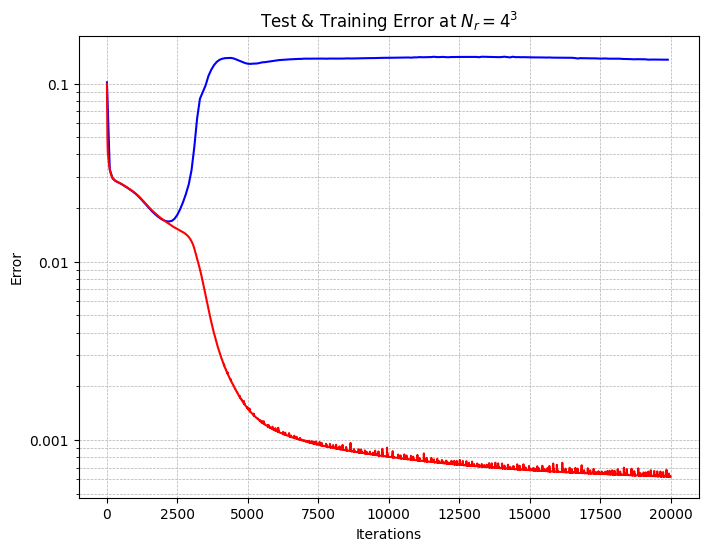

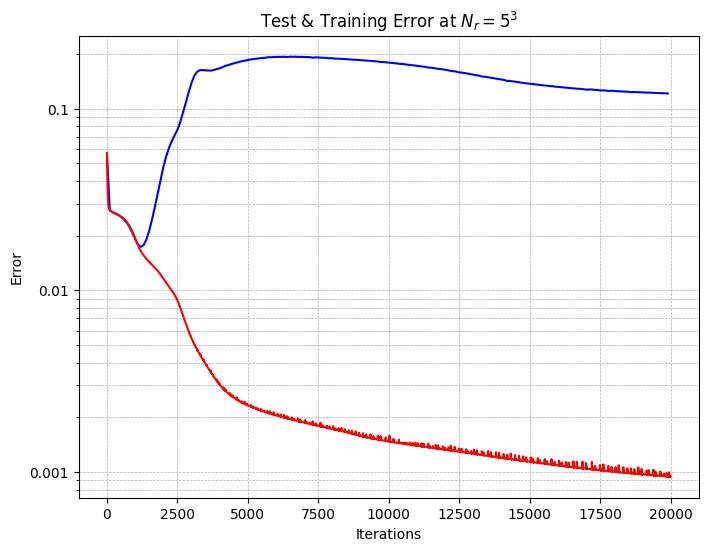

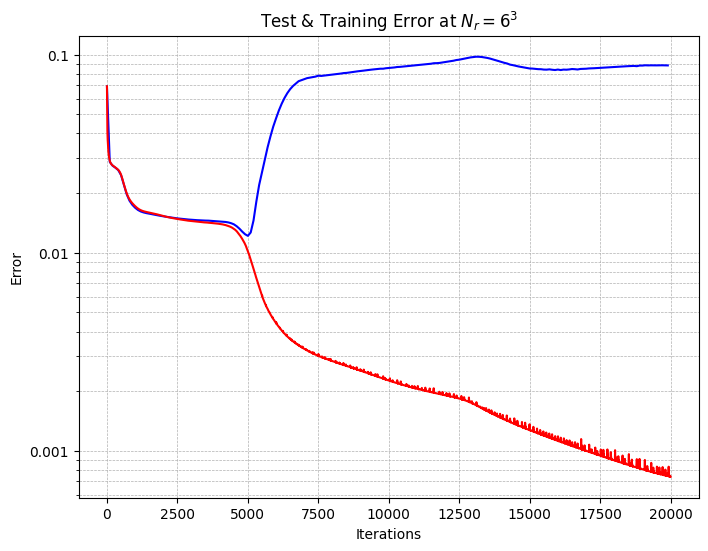

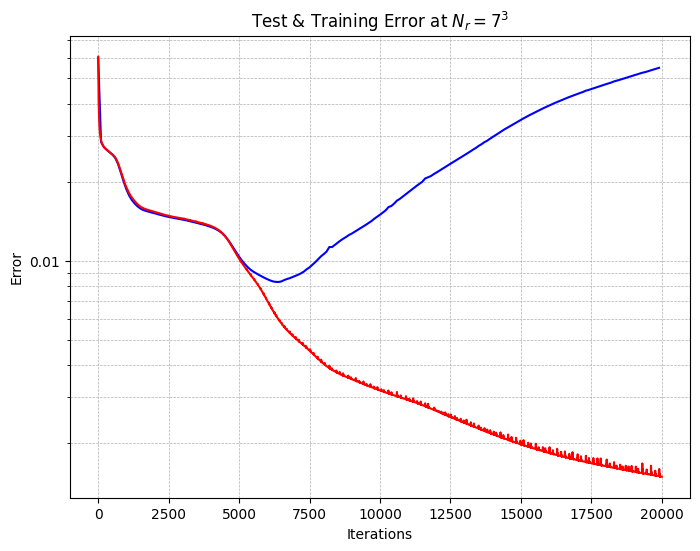

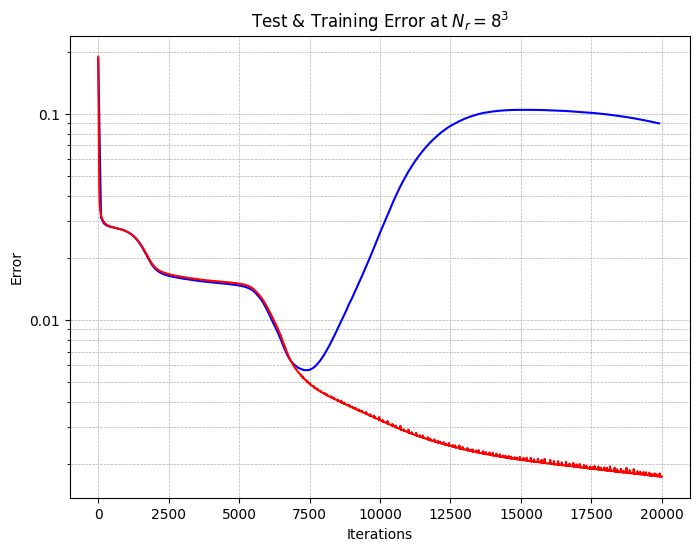

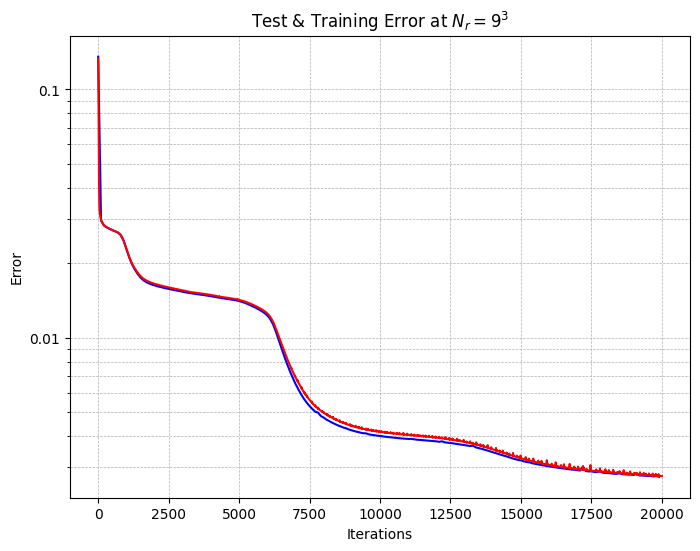

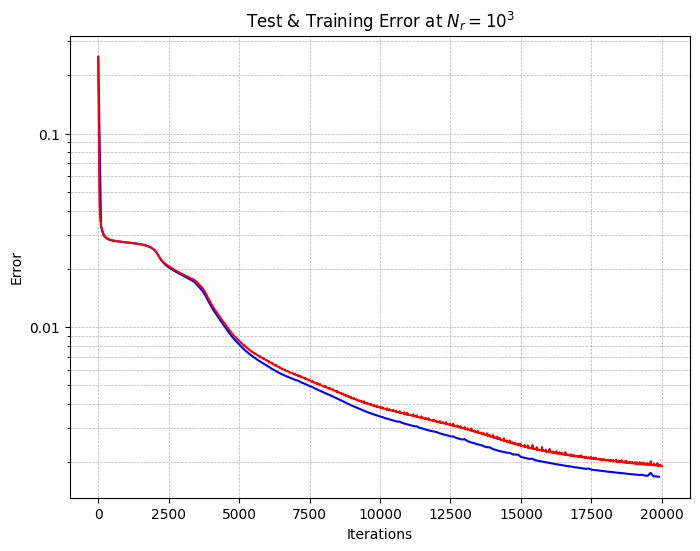

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker

N_rs = [3, 4, 5, 6, 7, 8, 9, 10]
results = np.load(f"../result_NS2_tanh3_dNs_[30]_Nrs_{N_rs}_i_20000.npz")
test_errors = results['test']
train_errors = results['train']


for i in range(len(N_rs)):
  plt.figure(figsize=(8,6))
  plt.plot(np.arange(200)*100, test_errors[i,0,:],color='blue', label="Test Error")
  plt.plot(np.arange(20000), train_errors[i,0,:],color='red', label='Training Error')
  plt.yscale('log')

  plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
  # plt.gca().yaxis.set_minor_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))

  plt.xlabel("Iterations")
  plt.ylabel("Error")
  # plt.title("True Error at multiple Ns")
  plt.title(f"Test & Training Error at $N_r={N_rs[i]}^3$")

  # plt.legend()
  plt.grid(True, which="both", linestyle="--", linewidth=0.5)
  plt.show()

In [ ]:
import torch
import numpy as np
from torch.autograd import grad
dev = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
N_t = 60 # cubed
N_0_t = 60 # squared
min_xyt, max_xyt = 0, 1
nu = 0.0001
rho = 1
loss_choice = torch.nn.HuberLoss()
lambda_0 = 1
lambda_1 = 0.3

def g_in(x,y):
    u = -1 * torch.cos(torch.pi * x) * torch.sin(torch.pi * y)
    v = torch.sin(torch.pi * x) * torch.cos(torch.pi * y)
    p = rho / -4 * (torch.cos(2*torch.pi*x)+torch.cos(2*torch.pi*y))
    return torch.stack((u,v, p),dim=-1)

class TanhCubed(torch.nn.Module):
    def forward(self, x):
        return torch.tanh(x) ** 3

class TwoLayerNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNN, self).__init__()
        self.layer1 = torch.nn.Linear(input_size, hidden_size)  # First layer (trainable)
        self.layer2 = torch.nn.Linear(hidden_size, output_size)  # Second layer (frozen)
        self.activation = TanhCubed()

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.layer2(x)  # This layer will not be trained
        return x
    
N = TwoLayerNN(3, 30, 3)
N.load_state_dict(torch.load("weights_NS_tanh_dNs_[30]_Nrs_[3, 5]_i_20000.pt",weights_only=True,map_location=torch.device('cpu'))['net_Nr_3'])
N.eval()



x_coll_test, y_coll_test, t_coll_test= torch.meshgrid(
          torch.linspace(min_xyt, max_xyt, N_t),
          torch.linspace(min_xyt, max_xyt, N_t),
          torch.linspace(0, max_xyt - min_xyt, N_t),
          indexing = "xy"
      )
coll_test = torch.stack([x_coll_test,y_coll_test,t_coll_test],dim=-1).reshape(-1,3).to(dev)

x_coll_0_test, y_coll_0_test = torch.meshgrid(
          torch.linspace(min_xyt, max_xyt, N_0_t),
          torch.linspace(min_xyt, max_xyt, N_0_t),
          indexing = "xy"
      )
coll_0_test = torch.stack([x_coll_0_test,y_coll_0_test],dim=-1).reshape(-1,2).to(dev)

x_test, y_test, t_test = coll_test[:,0], coll_test[:,1], coll_test[:,2]
x_test.requires_grad_(True)
y_test.requires_grad_(True)
t_test.requires_grad_(True)

x_0_test, y_0_test = coll_0_test[:,0],coll_0_test[:,1]
x_0_test.requires_grad_(True)
y_0_test.requires_grad_(True)

u0_test = N(torch.stack((x_0_test,y_0_test,torch.zeros_like(x_0_test)),dim=-1))
initial_loss_test = loss_choice(u0_test, g_in(x_0_test,y_0_test))

out_test = N(torch.stack((x_test, y_test, t_test),dim=-1))
u_test=out_test[...,0]
v_test=out_test[...,1]
p_test=out_test[...,2]

u_x_test = grad(u_test, x_test, torch.ones_like(u_test), create_graph = True)[0].squeeze() # du/dx
u_y_test = grad(u_test, y_test, torch.ones_like(u_test), create_graph = True)[0].squeeze() # du/dy
u_t_test = grad(u_test, t_test, torch.ones_like(u_test), create_graph = True)[0].squeeze()  # du/dt
v_x_test = grad(v_test, x_test, torch.ones_like(v_test), create_graph = True)[0].squeeze() # dv/dx
v_y_test = grad(v_test, y_test, torch.ones_like(v_test), create_graph = True)[0].squeeze() # dv/dy
v_t_test = grad(v_test, t_test, torch.ones_like(u_test), create_graph = True)[0].squeeze()  # dv/dt
p_x_test = grad(p_test, x_test, torch.ones_like(p_test), create_graph = True)[0].squeeze() # dp/dx
p_y_test = grad(p_test, y_test, torch.ones_like(p_test), create_graph = True)[0].squeeze() # dp/dy

u_xx_test = grad(u_x_test, x_test, torch.ones_like(u_x_test), create_graph = True)[0].squeeze() # d2u/dx2
u_yy_test = grad(u_y_test, y_test, torch.ones_like(u_y_test), create_graph = True)[0].squeeze() # d2u/dy2
v_xx_test = grad(v_x_test, x_test, torch.ones_like(v_x_test), create_graph = True)[0].squeeze() # d2v/dx2
v_yy_test = grad(v_y_test, y_test, torch.ones_like(v_y_test), create_graph = True)[0].squeeze() # d2v/dy2

x_mom_test = u_t_test + (u_test * u_x_test) + (v_test * u_y_test) + ((1 / rho) * p_x_test) - (nu * (u_xx_test + u_yy_test)) # x momentum
y_mom_test = v_t_test + (u_test * v_x_test) + (v_test * v_y_test) + ((1 / rho) * p_y_test) - (nu * (v_xx_test + v_yy_test)) # y momentum
cont_test = u_x_test + v_y_test # continuity

x_mom_loss_test = loss_choice(x_mom_test, torch.zeros_like(x_mom_test)) # x momentum loss
y_mom_loss_test = loss_choice(y_mom_test, torch.zeros_like(y_mom_test)) # y momentum loss
cont_loss_test = loss_choice(cont_test, torch.zeros_like(cont_test)) # continuity loss

# Compute the PDE loss
pde_loss_test = x_mom_loss_test + y_mom_loss_test + lambda_0 * cont_loss_test

print(pde_loss_test + lambda_1*initial_loss_test)

tensor(0.1377, grad_fn=<AddBackward0>)


In [36]:
out_test = N(torch.stack((x_test, y_test, t_test),dim=-1))
def u_sol(x,y,t):
    u = torch.sin(x) * torch.cos(y) * torch.exp(-2 * nu * t)
    v = -1 * torch.cos(x) * torch.sin(y) * torch.exp(-2 * nu * t)
    p = (rho / 4) * (torch.cos(2*x) + torch.cos(2*y)) * torch.exp(-4 * nu * t)
    return torch.stack((u,v,p),dim=-1)
out_true = u_sol(x_test, y_test, t_test)
print(out_true.shape)
print(torch.square(out_true - out_test).mean())

torch.Size([216000, 3])
tensor(0.0715, grad_fn=<MeanBackward0>)


# Plots

2.7922727e-06
1.2477877e-05
1.9439989e-05


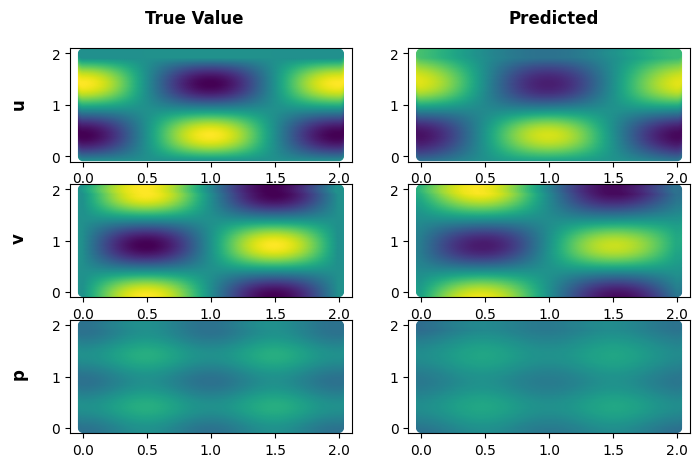

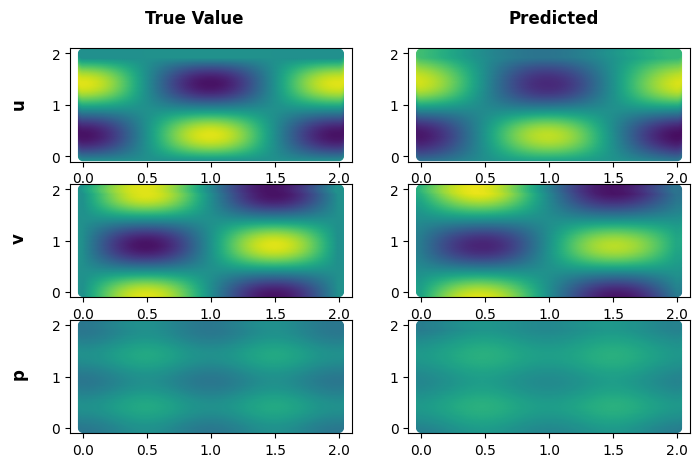

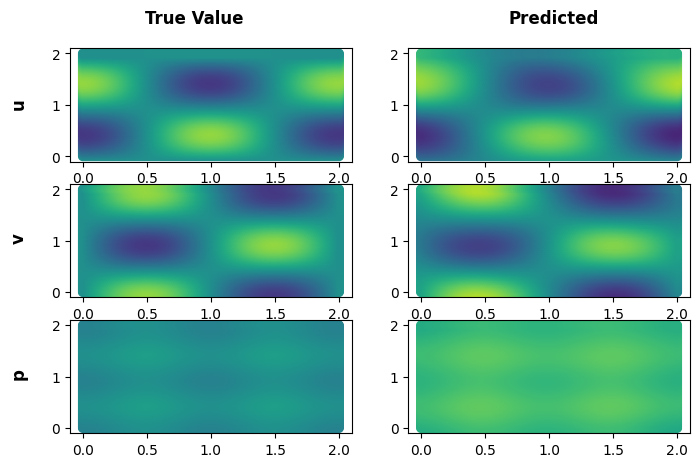

In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
from tqdm import tqdm

min_xyt, max_xyt = 0, 2
max_t=1
nu = 0.01
rho = 1

class TanhCubed(torch.nn.Module):
    def forward(self, x):
        return torch.tanh(x) ** 3
beta = 10**-3
k = 3
class ExpReLU(torch.nn.Module):
    def forward(self, x):
        return torch.exp(-1 * beta * x**2) * (torch.nn.ReLU()(x) ** k)

class TwoLayerNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNN, self).__init__()
        self.layer1 = torch.nn.Linear(input_size, hidden_size)  # First layer (trainable)
        self.layer2 = torch.nn.Linear(hidden_size, output_size)  # Second layer (frozen)
        self.activation = TanhCubed()

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.layer2(x)  # This layer will not be trained
        return x

NN = TwoLayerNN(3, 30, 3)
NN.load_state_dict(torch.load("../weights_NS2_tanh3_dNs_[30]_Nrs_[3, 4, 5, 6, 7, 8, 9, 10]_i_20000.pt",weights_only=True,map_location=torch.device('cpu'))['net_Nr_10'])
NN.eval()

def u_sol(x,y, t):
    u = -1 * torch.cos(torch.pi * x) * torch.sin(torch.pi * y) * torch.exp(-2 * (torch.pi**2) * nu * t)
    v = torch.sin(torch.pi * x) * torch.cos(torch.pi * y) * torch.exp(-2 * (torch.pi**2) * nu * t)
    p = rho / -4 * (torch.cos(2*torch.pi*x)+torch.cos(2*torch.pi*y)) * torch.exp(-4 * (torch.pi**2) * nu * t)
    return torch.stack((u,v, p),dim=-1)

for t_in in [0, 0.5*max_t, max_xyt]:
    gs = GridSpec(3, 2, width_ratios=[1]*2)
    fig = plt.figure(figsize=(8, 5))

    x, y = torch.meshgrid(
        torch.linspace(0, max_xyt, 128),
        torch.linspace(0, max_xyt, 128),
        indexing = "xy"
    )

    out = NN(torch.stack((x,y,torch.ones_like(x)*t_in),dim=-1)).detach().numpy()
    true_sol = u_sol(x,y,torch.ones_like(x)*t_in).detach().numpy()

    vminu = -1
    vmaxu = 1
    vminv = -1
    vmaxv = 1
    vminp = -2
    vmaxp = 2

    rel_er = (out - true_sol)
    print(rel_er[...,0].mean()**2)

    axut = fig.add_subplot(gs[0, 0])
    axut.scatter(x, y, c=true_sol[...,0], vmin=vminu, vmax=vmaxu)
    # axut.scatter(x, y, c=rel_er[...,0], vmin=vminu, vmax=vmaxu)
    axup = fig.add_subplot(gs[0, 1])
    axup.scatter(x, y, c=out[...,0], vmin=vminu, vmax=vmaxu)
    axvt = fig.add_subplot(gs[1, 0])
    axvt.scatter(x, y, c=true_sol[...,1], vmin=vminv, vmax=vmaxv)
    axvp = fig.add_subplot(gs[1, 1])
    axvp.scatter(x, y, c=out[...,1], vmin=vminv, vmax=vmaxv)
    axpt = fig.add_subplot(gs[2, 0])
    axpt.scatter(x, y, c=true_sol[...,2], vmin=vminp, vmax=vmaxp)
    axpp = fig.add_subplot(gs[2, 1])
    axpp.scatter(x, y, c=out[...,2], vmin=vminp, vmax=vmaxp)


    # Column labels
    col_labels = ['True Value', 'Predicted']
    for j, label in enumerate(col_labels):
        fig.text(0.28 + j * 0.45, 0.93, label, ha='center', fontsize=12, fontweight='bold')

    # Row labels
    row_labels = ['u', 'v', 'p']
    for i, label in enumerate(row_labels):
        fig.text(0.05, 0.77 - i * 0.27, label, va='center', rotation='vertical', fontsize=12, fontweight='bold')

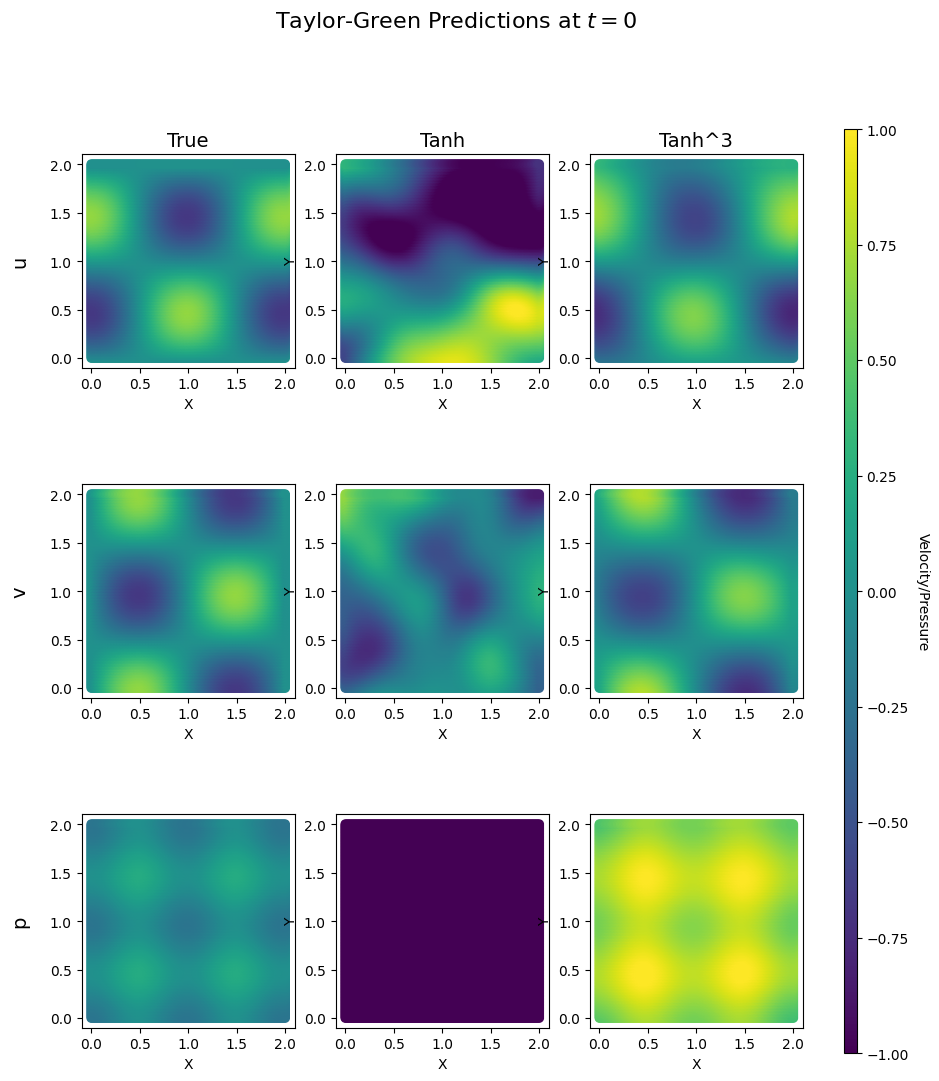

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

min_xyt, max_xyt = 0, 2
max_t=1
nu = 0.01
rho = 1

class TanhCubed(torch.nn.Module):
    def forward(self, x):
        return torch.tanh(x) ** 3
beta = 10**-3
k = 3
class ExpReLU(torch.nn.Module):
    def forward(self, x):
        return torch.exp(-1 * beta * x**2) * (torch.nn.ReLU()(x) ** k)

class TwoLayerNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNN, self).__init__()
        self.layer1 = torch.nn.Linear(input_size, hidden_size)  # First layer (trainable)
        self.layer2 = torch.nn.Linear(hidden_size, output_size)  # Second layer (frozen)
        self.activation = TanhCubed()

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.layer2(x)  # This layer will not be trained
        return x

NN = TwoLayerNN(3, 30, 3)
net_name = "../weights_NS2_tanh_dNs_[30]_Nrs_[3, 4, 5, 6, 7, 8, 9, 10]_i_20000.pt"
NN.load_state_dict(torch.load(net_name,weights_only=True,map_location=torch.device('cpu'))['net_Nr_10'])
NN.eval()
NN3 = TwoLayerNN(3, 30, 3)
net_name3 = "../weights_NS2_tanh3_dNs_[30]_Nrs_[3, 4, 5, 6, 7, 8, 9, 10]_i_20000.pt"
NN3.load_state_dict(torch.load(net_name3,weights_only=True,map_location=torch.device('cpu'))['net_Nr_10'])
NN3.eval()

def u_sol(x,y, t):
    u = -1 * torch.cos(torch.pi * x) * torch.sin(torch.pi * y) * torch.exp(-2 * (torch.pi**2) * nu * t)
    v = torch.sin(torch.pi * x) * torch.cos(torch.pi * y) * torch.exp(-2 * (torch.pi**2) * nu * t)
    p = rho / -4 * (torch.cos(2*torch.pi*x)+torch.cos(2*torch.pi*y)) * torch.exp(-4 * (torch.pi**2) * nu * t)
    return torch.stack((u, v, p),dim=-1)

x, y = torch.meshgrid(
        torch.linspace(0, max_xyt, 128),
        torch.linspace(0, max_xyt, 128),
        indexing = "xy"
    )
t = torch.ones_like(x) * 0

data = np.zeros([3, 3, 128, 128])
data[:, 0, :, :] = u_sol(x, y, t).detach().numpy().transpose((2, 0, 1))
data[:, 1, :, :] = NN(torch.stack((x, y, t), dim=-1)).detach().numpy().transpose((2, 0, 1))
data[:, 2, :, :] = NN3(torch.stack((x, y, t), dim=-1)).detach().numpy().transpose((2, 0, 1))

rows, cols = 3, 3
row_labels = ["u", "v", "p"]
col_labels = ["True", "Tanh", "Tanh^3"]

vmin, vmax = -1, 1

fig = plt.figure(figsize=(10, 12))
fig.suptitle(f"Taylor-Green Predictions at $t=0$", fontsize=16)

# Create gridspec with a narrow column on the right for the colorbar
gs = gridspec.GridSpec(rows, cols + 1, width_ratios=[1, 1, 1, 0.06], wspace=0.25, hspace=0.25)

axes = []
scatter_handles = []

# Create scatter subplots (only first 2 columns)
for r in range(rows):
    row_axes = []
    for c in range(cols):
        ax = fig.add_subplot(gs[r, c])
        row_axes.append(ax)

        cvals = data[r, c, :]
        sc = ax.scatter(x, y, c=cvals, vmin=vmin, vmax=vmax)

        ax.set_aspect("equal", adjustable="box")  # ensures square plots
        ax.set_xlabel("X")
        ax.set_ylabel("Y")

        scatter_handles.append(sc)
    axes.append(row_axes)

# Column titles
for c in range(cols):
    axes[0][c].set_title(col_labels[c], fontsize=14)

# Row labels
for r in range(rows):
    axes[r][0].set_ylabel(row_labels[r], fontsize=14, rotation=90, labelpad=15)

# One shared colorbar in the reserved column
cbar = fig.colorbar(
    scatter_handles[0],
    cax=fig.add_subplot(gs[:, -1])  # spanning all rows, last column
)
cbar.set_label("Velocity/Pressure", rotation=270, labelpad=15)

plt.show()
